# 패션 × 커머스 온톨로지 더미

**날짜:** 2026-08-18  
**목표:** 오픈소스 커머스(Olist)와 직접 수집한 한국 패션 시장 데이터를 같은 온톨로지 위에 올려, 현상이 어떻게 설명되는지 작은 그래프 더미로 본다.

이 노트북은 전체 지식그래프를 구축하지 않는다. **관측 가능한 한 장면**만 만든다.

| 층 | 역할 | 이번 더미에서 쓰는 데이터 |
|---|---|---|
| **TBox** | 개념 정의 (클래스·허용 관계) | `fashion_features.json`, 카테고리 family 맵 |
| **ABox** | 특정 날짜의 실제 인스턴스 | 무신사 상품 `6593921`, 검색 concept, Olist 패션 주문 |
| **Event** | 변화·상태 | 29CM 카테고리 믹스 드리프트, feature drift |

대표 장면은 2026-08-14 무신사의 **크롭 반팔 티셔츠**다. 배터리 온톨로지의 “온도 → BMS → 열폭주”에 해당하는 패션 쪽 경로는 대략 이렇게 읽으면 된다.

> 늦여름 → 검색 “반팔” → `sleeve:short` → 상품(크롭 반팔티) → 상의 랭킹 → 카탈로그/매출 상태


In [1]:
from __future__ import annotations

import json
import sqlite3
import sys
import warnings
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

warnings.filterwarnings("ignore", category=FutureWarning)

NB_ROOT = Path.cwd()
if not (NB_ROOT / "lib").exists():
    NB_ROOT = Path.cwd() / "notebooks"
sys.path.insert(0, str(NB_ROOT))

from lib.datasets import load_olist
from lib.plotting import chart_note, configure_matplotlib, finish_figure

font = configure_matplotlib()

SILHOUETTE_ROOT = Path("/Users/bhc/dev/datadrift/v2/silhouette_v2")
RUN_DATE = "2026-08-14"
FOCUS_PRODUCT_ID = "6593921"
FOCUS_SOURCE = "musinsa"

print("NB_ROOT:", NB_ROOT)
print("silhouette:", SILHOUETTE_ROOT.exists())
print("pandas", pd.__version__, "| font:", font)


NB_ROOT: /Users/bhc/dev/datadrift/v1/datadrift_app_engine/v3/notebooks
silhouette: True
pandas 3.0.5 | font: AppleGothic


## 1. 오픈소스 커머스: Olist 패션 카테고리

Olist에는 상품 이미지·한국어 상품명이 없다. 대신 **카테고리 코드와 주문 금액**이 있다.
패션 온톨로지에 바로 붙는 연결점은 `product_category_name` → 패션 family 매핑이다.


In [2]:
OLIST_FAMILY = {
    "fashion_bags_accessories": "bags",
    "fashion_shoes": "shoes",
    "fashion_male_clothing": "tops",
    "fashio_female_clothing": "tops",
    "fashion_childrens_clothes": "tops",
    "fashion_underwear_beach": "sport",
    "fashion_sport": "sport",
    "watches_gifts": None,
    "perfumery": None,
    "health_beauty": None,
}

olist = load_olist()
products = olist["products"].merge(olist["categories"], on="product_category_name", how="left")
fashion = products[products["product_category_name_english"].isin(OLIST_FAMILY)].copy()
fashion["ontology_family"] = fashion["product_category_name_english"].map(OLIST_FAMILY)

orders = olist["orders"][["order_id", "order_purchase_timestamp", "order_status"]].copy()
orders = orders[orders["order_status"] == "delivered"]
items = olist["items"][["order_id", "product_id", "price"]].merge(
    fashion[["product_id", "product_category_name_english", "ontology_family"]],
    on="product_id",
    how="inner",
)
fashion_orders = items.merge(orders, on="order_id", how="inner")
fashion_orders["month"] = fashion_orders["order_purchase_timestamp"].dt.to_period("M").astype(str)

olist_mix = (
    fashion_orders.groupby(["month", "product_category_name_english"], as_index=False)["price"]
    .sum()
    .rename(columns={"price": "gmv"})
)
olist_catalog = (
    fashion.groupby(["product_category_name_english", "ontology_family"], dropna=False)
    .size()
    .reset_index(name="n_products")
    .sort_values("n_products", ascending=False)
)

display(olist_catalog)
chart_note(
    "Olist 패션 카테고리는 온톨로지 family보다 거칠다. "
    "남성/여성/아동 의류는 모두 `tops`로 임시 매핑했지만, 실제로는 상의·하의가 섞여 있을 가능성이 크다. "
    "이 거친 매핑 자체가 온톨로지가 필요한 이유다."
)


,product_category_name_english,ontology_family,n_products
7,health_beauty,NaN,2444
9,watches_gifts,NaN,1329
8,perfumery,NaN,868
1,fashion_bags_accessories,bags,849
4,fashion_shoes,shoes,173
3,fashion_male_clothing,tops,95
6,fashion_underwear_beach,sport,53
0,fashio_female_clothing,tops,27
5,fashion_sport,sport,19
2,fashion_childrens_clothes,tops,5


Olist 패션 카테고리는 온톨로지 family보다 거칠다. 남성/여성/아동 의류는 모두 `tops`로 임시 매핑했지만, 실제로는 상의·하의가 섞여 있을 가능성이 크다. 이 거친 매핑 자체가 온톨로지가 필요한 이유다.

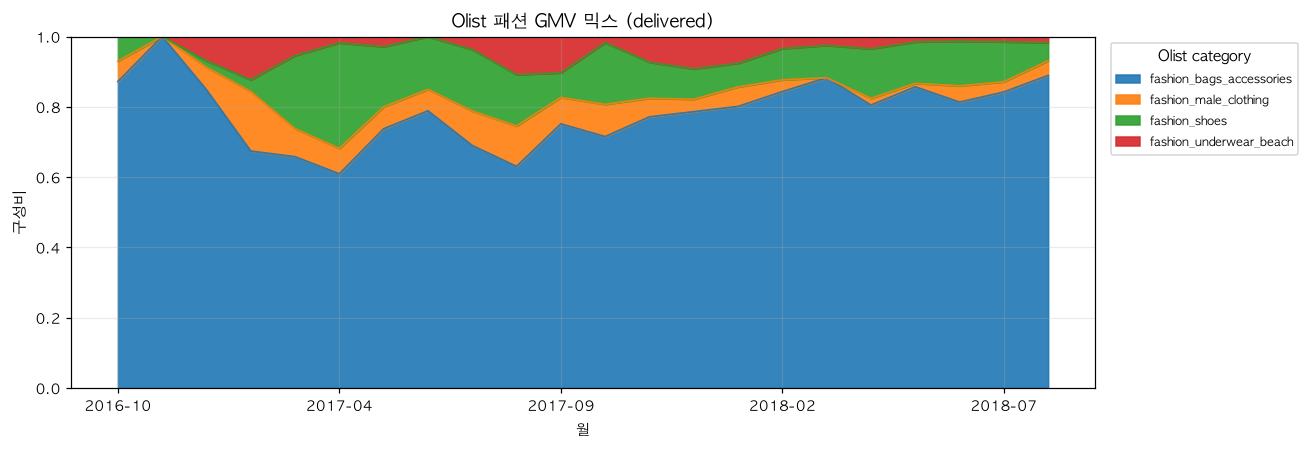

이 차트는 온톨로지의 **CatalogState** 인스턴스다. 총액이 같아도 가방/신발/의류 비중이 바뀌면 카탈로그 드리프트다. Olist에는 실루엣·소재 노드가 없으므로 여기까지가 공개 데이터로 설명 가능한 한계다.

In [3]:
core_cats = [
    "fashion_bags_accessories",
    "fashion_shoes",
    "fashion_male_clothing",
    "fashion_underwear_beach",
]
mix_core = olist_mix[olist_mix["product_category_name_english"].isin(core_cats)].copy()
mix_pivot = mix_core.pivot_table(
    index="month", columns="product_category_name_english", values="gmv", aggfunc="sum"
).fillna(0)
mix_share = mix_pivot.div(mix_pivot.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(12, 4.2))
mix_share.plot.area(ax=ax, stacked=True, alpha=0.9)
ax.set_title("Olist 패션 GMV 믹스 (delivered)")
ax.set_xlabel("월")
ax.set_ylabel("구성비")
ax.set_ylim(0, 1)
ax.legend(title="Olist category", loc="upper left", bbox_to_anchor=(1.01, 1))
finish_figure(fig, ax)
chart_note(
    "이 차트는 온톨로지의 **CatalogState** 인스턴스다. "
    "총액이 같아도 가방/신발/의류 비중이 바뀌면 카탈로그 드리프트다. "
    "Olist에는 실루엣·소재 노드가 없으므로 여기까지가 공개 데이터로 설명 가능한 한계다."
)


## 2. 직접 수집 데이터: 무신사 상품 한 건을 온톨로지 인스턴스로

같은 날짜(2026-08-14)의 검색 개념, 시각 특징, 랭킹·가격을 **하나의 상품**에 붙인다.
배터리 예시의 “셀 온도 센서 값”에 해당하는 것이 여기의 rank / price / visual feature weight다.


In [4]:
feat_path = SILHOUETTE_ROOT / "configs" / "fashion_features.json"
features = pd.DataFrame(json.loads(feat_path.read_text())["features"])[
    ["feature_id", "feature_type", "canonical_name_ko", "definition"]
]

prev_path = (
    SILHOUETTE_ROOT
    / "runs"
    / "survey_days"
    / RUN_DATE
    / "fused"
    / "intelligence"
    / "concept_prevalence.json"
)
prevalence = pd.DataFrame(json.loads(prev_path.read_text())["rows"])
search_prev = prevalence[
    (prevalence["channel"] == "customer_search")
    & (prevalence["concept_id"].isin(["sleeve:short", "garment:tshirt", "length:crop_top"]))
][
    ["concept_id", "prevalence", "weighted_share", "evidence_surface", "evidence_sentence", "effective_n"]
]

dom_path = (
    SILHOUETTE_ROOT
    / "runs"
    / "survey_days"
    / RUN_DATE
    / "fused"
    / "intelligence"
    / "numeric_dominance.json"
)
dominance = json.loads(dom_path.read_text())
cm_shift = next(
    ev
    for ev in dominance["events"]
    if ev.get("source") == "29cm" and ev.get("metric") == "category_dominance_shift"
)

signals_path = (
    SILHOUETTE_ROOT
    / "runs"
    / "survey_days"
    / RUN_DATE
    / "channels"
    / "musinsa"
    / "active"
    / "survey_signals.json"
)
signals = json.loads(signals_path.read_text())
focus_rows = [
    r
    for r in signals
    if (r.get("metadata") or {}).get("product_id") == FOCUS_PRODUCT_ID
    and r.get("category_label") == "상의"
    and r.get("gender") == "A"
    and r.get("age_band") == "AGE_BAND_ALL"
]
focus_obs = (
    pd.DataFrame(focus_rows)[["metric_name", "metric_value", "rank", "brand", "product", "observed_at"]]
    .drop_duplicates("metric_name")
    .sort_values("metric_name")
)
focus_meta = next(r for r in focus_rows if r["metric_name"] == "rank")

con = sqlite3.connect(SILHOUETTE_ROOT / "data" / "retail_images" / "visual_assignments.sqlite")
assign_row = con.execute(
    """
    SELECT category_family, weights_by_type_json, registry_version, prompt_contract_version
    FROM assignments
    WHERE source = ? AND product_id = ?
    """,
    (FOCUS_SOURCE, FOCUS_PRODUCT_ID),
).fetchone()
con.close()
family, weights_by_type, registry_version, prompt_contract = assign_row
top_features = {
    feat_type: max(weights, key=weights.get)
    for feat_type, weights in json.loads(weights_by_type).items()
    if isinstance(weights, dict) and weights
}

print("상품:", focus_meta["brand"], "·", focus_meta["product"])
print("family:", family, "|", registry_version, prompt_contract)
display(focus_obs)
display(pd.DataFrame(top_features.items(), columns=["feature_type", "feature_id"]))
display(search_prev.reset_index(drop=True))
print("29CM category_dominance_shift:", cm_shift["affected_entities"][:4])


상품: 언더오프 · 롤업 슬리브 크롭 반팔 티셔츠 블랙
family: tops | seed-2026-08-06-visual-families visual-prompt-v3-family-practical


,metric_name,metric_value,rank,brand,product,observed_at
2,buyers_now,30.0,4,언더오프,롤업 슬리브 크롭 반팔 티셔츠 블랙,2026-08-14T03:52:16Z
4,discount_rate,48.0,4,언더오프,롤업 슬리브 크롭 반팔 티셔츠 블랙,2026-08-14T03:52:16Z
5,price,19530.0,4,언더오프,롤업 슬리브 크롭 반팔 티셔츠 블랙,2026-08-14T03:52:16Z
0,rank,4.0,4,언더오프,롤업 슬리브 크롭 반팔 티셔츠 블랙,2026-08-14T03:52:16Z
3,review_count,783.0,4,언더오프,롤업 슬리브 크롭 반팔 티셔츠 블랙,2026-08-14T03:52:16Z
1,viewers_now,636.0,4,언더오프,롤업 슬리브 크롭 반팔 티셔츠 블랙,2026-08-14T03:52:16Z


,feature_type,feature_id
0,aesthetic,aesthetic:capsule
1,color,color:black
2,garment,garment:tshirt
3,length,length:crop_top
4,material,material:cotton
5,neckline,neckline:crew
6,pattern,pattern:solid
7,silhouette,silhouette:boxy
8,sleeve,sleeve:short


,concept_id,prevalence,weighted_share,evidence_surface,evidence_sentence,effective_n
0,sleeve:short,0.063636,0.056555,반팔,반팔티,110.0
1,garment:tshirt,0.009091,0.007993,티셔츠,티셔츠,110.0
2,length:crop_top,0.009091,0.007959,크롭,크롭 반팔,110.0
3,sleeve:short,0.063636,0.056555,반팔,반팔티,110.0
4,garment:tshirt,0.009091,0.007993,티셔츠,티셔츠,110.0
5,length:crop_top,0.009091,0.007959,크롭,크롭 반팔,110.0


29CM category_dominance_shift: [{'entity': '상의', 'delta': -0.062153}, {'entity': '홈웨어', 'delta': 0.038392}, {'entity': '아우터', 'delta': 0.037503}, {'entity': '하의', 'delta': -0.036429}]


## 3. TBox 더미: 클래스가 허용하는 관계

배터리 온톨로지에서 `Temperature`와 `ThermalRunaway`가 다른 클래스이듯, 패션에서도 소재·검색어·랭킹은 같은 종류의 노드가 아니다.
아래는 이번 더미가 쓰는 **최소 TBox**다.


In [5]:
tbox = pd.DataFrame(
    [
        ["Season", "환경", "늦여름", "배터리의 외기온에 해당"],
        ["SearchSignal", "수요", "검색 ‘반팔’", "센서 값. 상품 자체가 아님"],
        ["FashionFeature", "의미", "sleeve:short", "온톨로지 개념. TBox 시드"],
        ["Product", "공급", "무신사 6593921", "특정 SKU 인스턴스"],
        ["Brand", "행위자", "언더오프", "상품을 공급하는 주체"],
        ["Marketplace", "시스템", "무신사 / 29CM / Olist", "배터리의 BMS·팩에 해당"],
        ["MarketObservation", "관측", "rank=4, price=19530", "시점·채널이 붙은 측정"],
        ["DemandState", "상태", "반팔 수요 활성", "해석된 상태. 원본 측정이 아님"],
        ["CatalogState", "상태", "상의 비중 하락", "믹스 변화"],
        ["DriftEvent", "사건", "category_dominance_shift", "baseline 대비 변화"],
        ["SalesOutcome", "결과", "Olist fashion GMV", "향후 기업 매출이 들어올 자리"],
    ],
    columns=["class", "module", "이번 더미 인스턴스", "배터리 비유 / 메모"],
)
display(tbox)

allowed = pd.DataFrame(
    [
        ["Season", "MAY_INFLUENCE", "SearchSignal", "가설. 인과 아님"],
        ["SearchSignal", "MENTIONS", "FashionFeature", "관측"],
        ["Product", "HAS_FEATURE", "FashionFeature", "시각 모델 할당"],
        ["Product", "INSTANCE_OF", "CategoryFamily", "상의=tops"],
        ["Brand", "OFFERS", "Product", "관측"],
        ["Product", "LISTED_ON", "Marketplace", "관측"],
        ["Marketplace", "OBSERVES", "MarketObservation", "랭킹/가격/리뷰"],
        ["SearchSignal", "PRECEDES", "DemandState", "시간 정렬이 필요"],
        ["DemandState", "ASSOCIATED_WITH", "MarketObservation", "통계적 연관"],
        ["DriftEvent", "OBSERVED_AS", "CatalogState", "드리프트 사건을 상태로 승격"],
        ["OlistCategory", "MAPS_TO", "CategoryFamily", "공개 데이터의 거친 브릿지"],
        ["CatalogState", "ASSOCIATED_WITH", "SalesOutcome", "기업 매출 연결점"],
    ],
    columns=["domain", "relation", "range", "증거 강도"],
)
display(allowed)


,class,module,이번 더미 인스턴스,배터리 비유 / 메모
0,Season,환경,늦여름,배터리의 외기온에 해당
1,SearchSignal,수요,검색 ‘반팔’,센서 값. 상품 자체가 아님
2,FashionFeature,의미,sleeve:short,온톨로지 개념. TBox 시드
3,Product,공급,무신사 6593921,특정 SKU 인스턴스
4,Brand,행위자,언더오프,상품을 공급하는 주체
5,Marketplace,시스템,무신사 / 29CM / Olist,배터리의 BMS·팩에 해당
6,MarketObservation,관측,"rank=4, price=19530",시점·채널이 붙은 측정
7,DemandState,상태,반팔 수요 활성,해석된 상태. 원본 측정이 아님
8,CatalogState,상태,상의 비중 하락,믹스 변화
9,DriftEvent,사건,category_dominance_shift,baseline 대비 변화


,domain,relation,range,증거 강도
0,Season,MAY_INFLUENCE,SearchSignal,가설. 인과 아님
1,SearchSignal,MENTIONS,FashionFeature,관측
2,Product,HAS_FEATURE,FashionFeature,시각 모델 할당
3,Product,INSTANCE_OF,CategoryFamily,상의=tops
4,Brand,OFFERS,Product,관측
5,Product,LISTED_ON,Marketplace,관측
6,Marketplace,OBSERVES,MarketObservation,랭킹/가격/리뷰
7,SearchSignal,PRECEDES,DemandState,시간 정렬이 필요
8,DemandState,ASSOCIATED_WITH,MarketObservation,통계적 연관
9,DriftEvent,OBSERVED_AS,CatalogState,드리프트 사건을 상태로 승격


## 4. ABox 더미 그래프: 한 장의 현상 설명

아래 트리플은 두 종류다.

- **observed**: 파일에서 읽은 사실
- **dummy**: 현상을 잇기 위해 넣은 가설 관계 (`MAY_INFLUENCE` 등)

배터리 그래프처럼 “초래함”으로 모두 잇지 않는다. 색으로 증거 강도를 구분한다.


In [6]:
product_label = f"{focus_meta['brand']} {focus_meta['product']}"
rank_val = float(focus_obs.loc[focus_obs["metric_name"] == "rank", "metric_value"].iloc[0])
price_val = float(focus_obs.loc[focus_obs["metric_name"] == "price", "metric_value"].iloc[0])
disc_val = float(focus_obs.loc[focus_obs["metric_name"] == "discount_rate", "metric_value"].iloc[0])

nodes = [
    {"id": "season:late_summer", "label": "늦여름\n2026-08", "cls": "Season", "layer": 0},
    {"id": "search:short_sleeve", "label": "검색 ‘반팔’\nshare 5.7%", "cls": "SearchSignal", "layer": 1},
    {"id": "journal:runway", "label": "저널 runway\nfeature drift", "cls": "EditorialSignal", "layer": 1},
    {"id": "feat:sleeve_short", "label": "sleeve:short\n반팔", "cls": "FashionFeature", "layer": 2},
    {"id": "feat:tshirt", "label": "garment:tshirt\n티셔츠", "cls": "FashionFeature", "layer": 2},
    {"id": "feat:crop", "label": "length:crop_top\n크롭", "cls": "FashionFeature", "layer": 2},
    {"id": "feat:black", "label": "color:black\n블랙", "cls": "FashionFeature", "layer": 2},
    {"id": "family:tops", "label": "family:tops\n상의", "cls": "CategoryFamily", "layer": 2},
    {"id": "brand:underoff", "label": "브랜드\n언더오프", "cls": "Brand", "layer": 3},
    {"id": f"product:{FOCUS_PRODUCT_ID}", "label": "크롭 반팔 티셔츠\n#6593921", "cls": "Product", "layer": 3},
    {"id": "mkt:musinsa", "label": "마켓\n무신사", "cls": "Marketplace", "layer": 4},
    {"id": "mkt:29cm", "label": "마켓\n29CM", "cls": "Marketplace", "layer": 4},
    {"id": "mkt:olist", "label": "마켓\nOlist", "cls": "Marketplace", "layer": 4},
    {"id": "obs:rank", "label": f"상의 랭킹\n{rank_val:.0f}위", "cls": "MarketObservation", "layer": 4},
    {"id": "obs:price", "label": f"19,530원\n할인 {disc_val:.0f}%", "cls": "MarketObservation", "layer": 4},
    {"id": "state:demand_short", "label": "DemandState\n반팔 수요 활성", "cls": "DemandState", "layer": 5},
    {"id": "event:29cm_mix", "label": "DriftEvent\n상의↓ 아우터↑", "cls": "DriftEvent", "layer": 5},
    {"id": "state:olist_mix", "label": "CatalogState\nOlist 패션 믹스", "cls": "CatalogState", "layer": 5},
]

edges = [
    ("season:late_summer", "search:short_sleeve", "MAY_INFLUENCE", "dummy"),
    ("search:short_sleeve", "feat:sleeve_short", "MENTIONS", "observed"),
    ("journal:runway", "feat:tshirt", "MENTIONS", "dummy"),
    (f"product:{FOCUS_PRODUCT_ID}", "feat:sleeve_short", "HAS_FEATURE", "observed"),
    (f"product:{FOCUS_PRODUCT_ID}", "feat:tshirt", "HAS_FEATURE", "observed"),
    (f"product:{FOCUS_PRODUCT_ID}", "feat:crop", "HAS_FEATURE", "observed"),
    (f"product:{FOCUS_PRODUCT_ID}", "feat:black", "HAS_FEATURE", "observed"),
    (f"product:{FOCUS_PRODUCT_ID}", "family:tops", "INSTANCE_OF", "observed"),
    ("brand:underoff", f"product:{FOCUS_PRODUCT_ID}", "OFFERS", "observed"),
    (f"product:{FOCUS_PRODUCT_ID}", "mkt:musinsa", "LISTED_ON", "observed"),
    ("mkt:musinsa", "obs:rank", "OBSERVES", "observed"),
    ("mkt:musinsa", "obs:price", "OBSERVES", "observed"),
    (f"product:{FOCUS_PRODUCT_ID}", "obs:rank", "HAS_OBSERVATION", "observed"),
    (f"product:{FOCUS_PRODUCT_ID}", "obs:price", "HAS_OBSERVATION", "observed"),
    ("search:short_sleeve", "state:demand_short", "PRECEDES", "dummy"),
    ("obs:rank", "state:demand_short", "ASSOCIATED_WITH", "dummy"),
    ("mkt:29cm", "event:29cm_mix", "OBSERVES", "observed"),
    ("family:tops", "event:29cm_mix", "AFFECTED_BY", "observed"),
    ("mkt:olist", "state:olist_mix", "OBSERVES", "observed"),
    ("family:tops", "state:olist_mix", "MAPS_TO", "dummy"),
    ("state:demand_short", "event:29cm_mix", "MAY_DIVERGE_FROM", "dummy"),
]

triples = pd.DataFrame(edges, columns=["source", "relation", "target", "evidence"])
triples.insert(0, "run_date", RUN_DATE)
display(triples)


,run_date,source,relation,target,evidence
0,2026-08-14,season:late_summer,search:short_sleeve,MAY_INFLUENCE,dummy
1,2026-08-14,search:short_sleeve,feat:sleeve_short,MENTIONS,observed
2,2026-08-14,journal:runway,feat:tshirt,MENTIONS,dummy
3,2026-08-14,product:6593921,feat:sleeve_short,HAS_FEATURE,observed
4,2026-08-14,product:6593921,feat:tshirt,HAS_FEATURE,observed
5,2026-08-14,product:6593921,feat:crop,HAS_FEATURE,observed
6,2026-08-14,product:6593921,feat:black,HAS_FEATURE,observed
7,2026-08-14,product:6593921,family:tops,INSTANCE_OF,observed
8,2026-08-14,brand:underoff,product:6593921,OFFERS,observed
9,2026-08-14,product:6593921,mkt:musinsa,LISTED_ON,observed


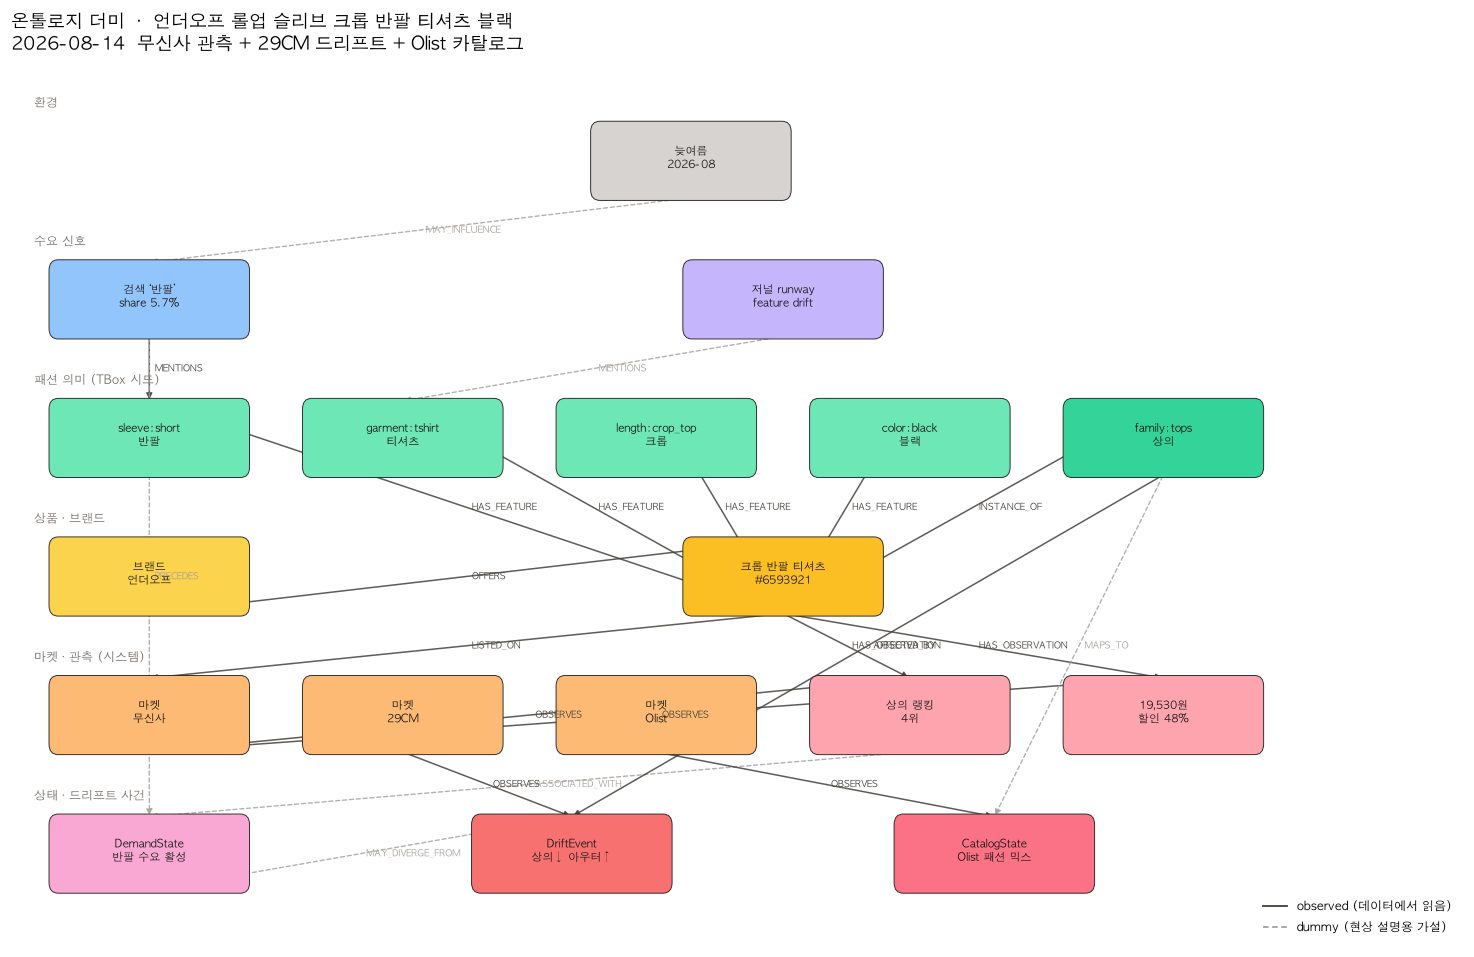

In [7]:
LAYER_Y = {0: 5.4, 1: 4.35, 2: 3.3, 3: 2.25, 4: 1.2, 5: 0.15}
LAYER_TITLE = {
    0: "환경",
    1: "수요 신호",
    2: "패션 의미 (TBox 시드)",
    3: "상품 · 브랜드",
    4: "마켓 · 관측 (시스템)",
    5: "상태 · 드리프트 사건",
}
CLS_COLOR = {
    "Season": "#d6d3d1",
    "SearchSignal": "#93c5fd",
    "EditorialSignal": "#c4b5fd",
    "FashionFeature": "#6ee7b7",
    "CategoryFamily": "#34d399",
    "Brand": "#fcd34d",
    "Product": "#fbbf24",
    "Marketplace": "#fdba74",
    "MarketObservation": "#fda4af",
    "DemandState": "#f9a8d4",
    "DriftEvent": "#f87171",
    "CatalogState": "#fb7185",
}
REL_COLOR = {
    "observed": "#44403c",
    "dummy": "#a8a29e",
}

by_layer = defaultdict(list)
for n in nodes:
    by_layer[n["layer"]].append(n)

pos = {}
for layer, group in by_layer.items():
    xs = [i * (11 / max(len(group), 1)) + 0.8 for i in range(len(group))]
    if len(group) == 1:
        xs = [5.5]
    for n, x in zip(group, xs):
        pos[n["id"]] = (x, LAYER_Y[layer])

fig, ax = plt.subplots(figsize=(13.5, 8.8))
ax.set_xlim(-0.4, 12.2)
ax.set_ylim(-0.55, 6.15)
ax.axis("off")
ax.set_title(
    f"온톨로지 더미  ·  {product_label}\n{RUN_DATE}  무신사 관측 + 29CM 드리프트 + Olist 카탈로그",
    loc="left",
    pad=8,
)

for layer, title in LAYER_TITLE.items():
    ax.text(-0.2, LAYER_Y[layer] + 0.38, title, fontsize=8, color="#78716c", ha="left", va="bottom")

for src, dst, rel, ev in edges:
    x1, y1 = pos[src]
    x2, y2 = pos[dst]
    ax.add_patch(
        FancyArrowPatch(
            (x1, y1 - 0.28),
            (x2, y2 + 0.28),
            arrowstyle="-|>",
            mutation_scale=8,
            linewidth=1.0 if ev == "observed" else 0.9,
            linestyle="solid" if ev == "observed" else (0, (3, 2)),
            color=REL_COLOR[ev],
            alpha=0.85,
            shrinkA=1,
            shrinkB=1,
        )
    )
    mx, my = (x1 + x2) / 2, (y1 + y2) / 2
    ax.text(mx + 0.05, my, rel, fontsize=6.2, color=REL_COLOR[ev], ha="left", va="center")

node_lookup = {n["id"]: n for n in nodes}
for nid, (x, y) in pos.items():
    n = node_lookup[nid]
    w, h = 1.7, 0.56
    ax.add_patch(
        FancyBboxPatch(
            (x - w / 2, y - h / 2),
            w,
            h,
            boxstyle="round,pad=0.02,rounding_size=0.08",
            facecolor=CLS_COLOR[n["cls"]],
            edgecolor="#292524",
            linewidth=0.6,
        )
    )
    ax.text(x, y + 0.02, n["label"], ha="center", va="center", fontsize=7.2, color="#1c1917")

ax.plot([], [], color=REL_COLOR["observed"], label="observed (데이터에서 읽음)")
ax.plot([], [], color=REL_COLOR["dummy"], linestyle=(0, (3, 2)), label="dummy (현상 설명용 가설)")
ax.legend(loc="lower right", frameon=False, fontsize=8)
fig.tight_layout()
plt.show()


## 5. 이 그래프가 설명하는 현상

배터리 예시와 같은 방식으로, 위 더미를 한 줄의 서사로 읽으면 다음과 같다.

1. **환경**: 2026-08-14는 늦여름이다. (`Season`) — 더미 컨텍스트
2. **수요 센서**: 무신사 고객 검색에서 “반팔”이 `sleeve:short`를 가리킨다. 근거 문장: `반팔티`
3. **의미 계층**: 시각 모델이 상품 `6593921`에 `garment:tshirt`, `sleeve:short`, `length:crop_top`, `color:black`을 붙인다
4. **시스템 관측**: 무신사는 이 SKU를 상의 랭킹 상위, 19,530원, 48% 할인으로 관측한다
5. **상태**: 반팔 수요는 아직 활성이다 (`DemandState`)
6. **어긋남**: 같은 날 29CM 카탈로그는 상의 비중이 줄고 아우터·홈웨어가 늘었다 (`DriftEvent`)
7. **공개 데이터 브릿지**: Olist의 `fashion_male_clothing` 같은 거친 카테고리는 같은 `tops` family로만 연결된다. 반팔/크롭 같은 속성 노드는 Olist에 없다

핵심은 5와 6이 **동시에** 존재한다는 점이다. 수요 신호(반팔)와 공급 믹스(아우터 이동)가 어긋난 상태를 온톨로지는 `MAY_DIVERGE_FROM`으로 표현한다. 통계 차트만 보면 둘 다 “드리프트”로 보이지만, 그래프에서는 **어느 층이 움직였는지**가 갈린다.


In [8]:
story = pd.DataFrame(
    [
        ["환경", "Season", "늦여름", "캘린더", "dummy"],
        ["수요", "SearchSignal", "반팔", "concept_prevalence customer_search", "observed"],
        ["의미", "FashionFeature", ", ".join(top_features.values()), "visual_assignments.sqlite", "observed"],
        ["상품", "Product", f"{FOCUS_SOURCE}:{FOCUS_PRODUCT_ID}", "survey_signals.json", "observed"],
        ["시스템", "Marketplace", "musinsa 랭킹/가격", "survey_signals.json", "observed"],
        ["상태", "DemandState", "반팔 수요 활성", "검색+랭킹을 묶어 승격", "dummy"],
        ["사건", "DriftEvent", "29CM 상의↓ 아우터↑", "numeric_dominance.json", "observed"],
        ["벤치마크", "CatalogState", "Olist 패션 GMV 믹스", "olist_*_dataset.csv", "observed"],
    ],
    columns=["층", "class", "값", "출처", "증거"],
)
display(story)

chart_note(
    """
**향후 기업 매출이 들어오면 어디에 붙는가?**

- `Product`에 `HAS_OBSERVATION / GMV` 를 추가한다 (POS 라인)
- `CatalogState ASSOCIATED_WITH SalesOutcome` 를 검증 가능한 엣지로 바꾼다
- 지금 더미의 `DemandState`가 실제 판매를 **선행했는지** `PRECEDES` 윈도우로 측정한다

공개 Olist 데이터는 그 연결을 흉내 내는 벤치마크이고, 무신사·29CM 수집 데이터는 패션 의미 층을 채우는 센서다.
"""
)


,층,class,값,출처,증거
0,환경,Season,늦여름,캘린더,dummy
1,수요,SearchSignal,반팔,concept_prevalence customer_search,observed
2,의미,FashionFeature,"aesthetic:capsule, color:black, garment:tshirt...",visual_assignments.sqlite,observed
3,상품,Product,musinsa:6593921,survey_signals.json,observed
4,시스템,Marketplace,musinsa 랭킹/가격,survey_signals.json,observed
5,상태,DemandState,반팔 수요 활성,검색+랭킹을 묶어 승격,dummy
6,사건,DriftEvent,29CM 상의↓ 아우터↑,numeric_dominance.json,observed
7,벤치마크,CatalogState,Olist 패션 GMV 믹스,olist_*_dataset.csv,observed


**향후 기업 매출이 들어오면 어디에 붙는가?**

- `Product`에 `HAS_OBSERVATION / GMV` 를 추가한다 (POS 라인)
- `CatalogState ASSOCIATED_WITH SalesOutcome` 를 검증 가능한 엣지로 바꾼다
- 지금 더미의 `DemandState`가 실제 판매를 **선행했는지** `PRECEDES` 윈도우로 측정한다

공개 Olist 데이터는 그 연결을 흉내 내는 벤치마크이고, 무신사·29CM 수집 데이터는 패션 의미 층을 채우는 센서다.

## 다음에 키울 것

이 더미가 보여주는 구조는 이미 충분하다. 규모만 키우면 된다.

1. `HAS_FEATURE`를 상품 1개가 아니라 일별 코호트 전체로 확장
2. `PRECEDES`를 더미가 아니라 검색→랭킹→(미래)매출의 lag 측정으로 교체
3. Olist 카테고리 매핑을 `MAPS_TO` 테이블로 고정하고, 한국 카테고리 코드와 같은 family로 정렬
4. 관계 승격 규칙: `OBSERVED` → `ASSOCIATED_WITH` → `MAY_INFLUENCE` → `CAUSES`
